<a href="https://colab.research.google.com/github/dana1975/face/blob/main/face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import zipfile
import os

# Upload ZIP
uploaded = files.upload()

# Extract ZIP
with zipfile.ZipFile("database.zip", 'r') as zip_ref:
    zip_ref.extractall("database")

print("Done extracting.")


Saving database.zip to database (1).zip
Done extracting.


In [4]:
import numpy as np
import cv2
import os
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
LBP_POINTS = 8
LBP_RADIUS = 1
LBP_METHOD = 'uniform'

emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}


In [6]:
def load_images_from_folder(base_path):
    features = []
    labels = []
    for emotion, label in emotion_map.items():
        folder_path = os.path.join(base_path, 'test', emotion)
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None and img.shape == (48, 48):
                lbp = local_binary_pattern(img, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)
                (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
                hist = hist.astype("float")
                hist /= (hist.sum() + 1e-6)
                features.append(hist)
                labels.append(label)
    return np.array(features), np.array(labels)

X, y = load_images_from_folder("database")


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.25      0.21       193
           1       0.00      0.00      0.00        26
           2       0.15      0.15      0.15       217
           3       0.27      0.33      0.30       353
           4       0.21      0.18      0.20       240
           5       0.23      0.14      0.17       161
           6       0.18      0.13      0.15       246

    accuracy                           0.21      1436
   macro avg       0.17      0.17      0.17      1436
weighted avg       0.20      0.21      0.20      1436



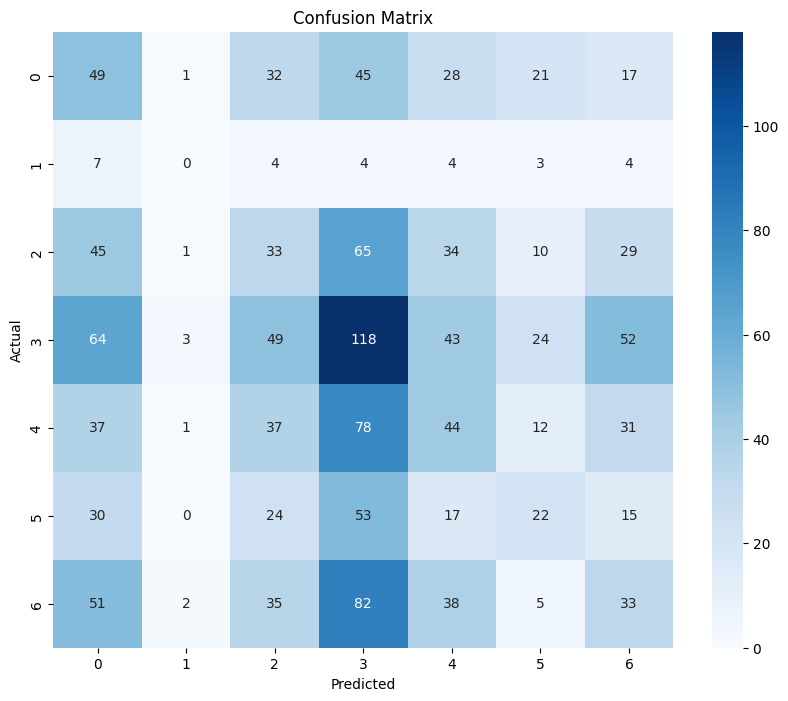

In [8]:
y_pred = knn.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


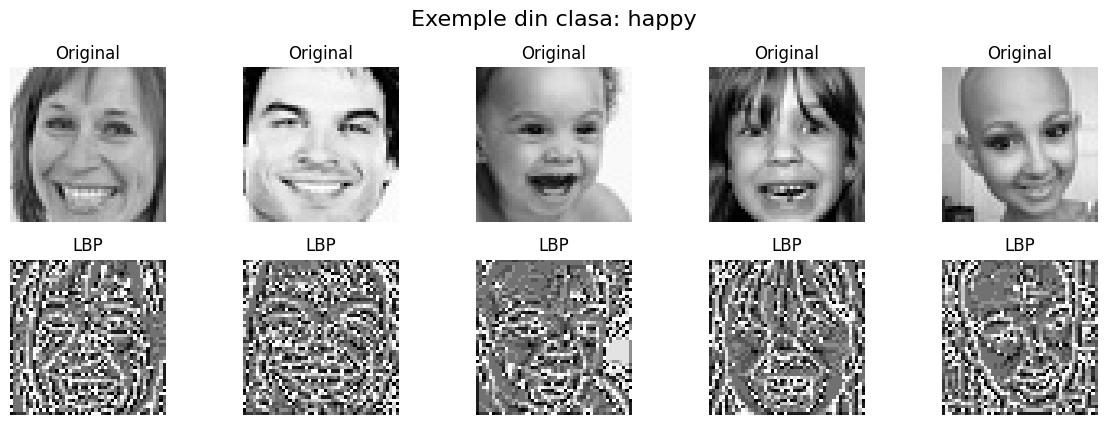

In [14]:
# 7. Opțional: Afișare imagini + LBP
import random

emotion_class = 'happy'  # modifică după nevoie
sample_folder = os.path.join("database", 'test', emotion_class)
sample_images = random.sample(os.listdir(sample_folder), 5)

plt.figure(figsize=(12, 4))
for i, file in enumerate(sample_images):
    img_path = os.path.join(sample_folder, file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    lbp = local_binary_pattern(img, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)

    # Original image
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # LBP image
    plt.subplot(2, 5, i + 6)
    plt.imshow(lbp, cmap='gray')
    plt.title('LBP')
    plt.axis('off')

plt.tight_layout()
plt.suptitle(f'Exemple din clasa: {emotion_class}', fontsize=16, y=1.05)
plt.show()


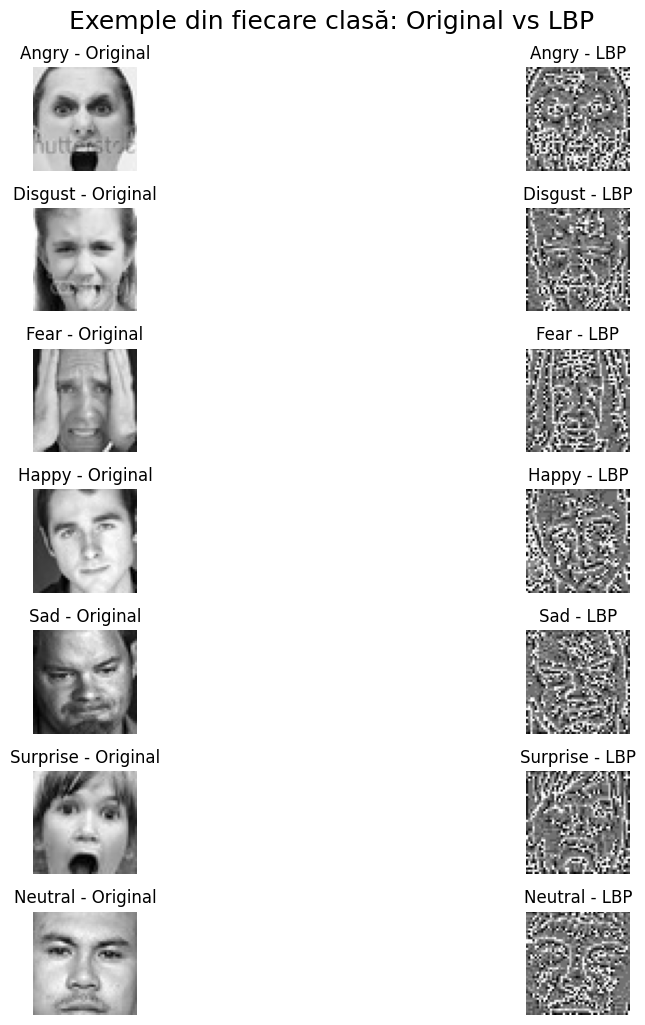

In [15]:
# Afișare imagini și LBP pentru fiecare clasă de emoție
import random

plt.figure(figsize=(14, 10))

for idx, (emotion_class, label) in enumerate(emotion_map.items()):
    folder_path = os.path.join("database", 'test', emotion_class)
    sample_images = random.sample(os.listdir(folder_path), 1)  # 1 imagine per clasă
    img_path = os.path.join(folder_path, sample_images[0])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    lbp = local_binary_pattern(img, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)

    # Original
    plt.subplot(7, 2, 2 * idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'{emotion_class.capitalize()} - Original')
    plt.axis('off')

    # LBP
    plt.subplot(7, 2, 2 * idx + 2)
    plt.imshow(lbp, cmap='gray')
    plt.title(f'{emotion_class.capitalize()} - LBP')
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Exemple din fiecare clasă: Original vs LBP', fontsize=18, y=1.02)
plt.show()


In [16]:
img = cv2.resize(img, (48, 48))


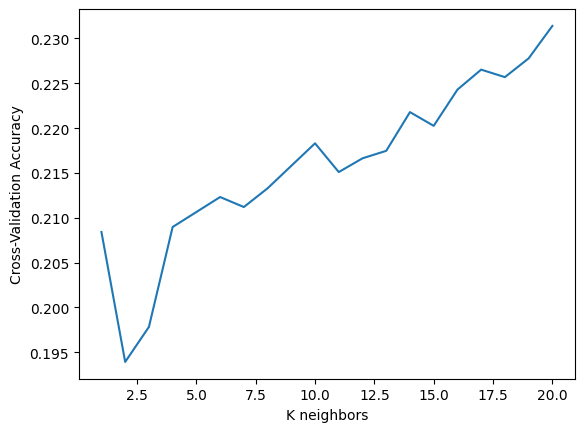

In [17]:
from sklearn.model_selection import cross_val_score
neighbors_range = range(1, 21)
cv_scores = []
for k in neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores.append(np.mean(cross_val_score(knn, X, y, cv=5)))
plt.plot(neighbors_range, cv_scores)
plt.xlabel('K neighbors')
plt.ylabel('Cross-Validation Accuracy')
plt.show()


In [1]:
def load_images_from_folder(base_path):
    features = []
    labels = []
    images = []  # Lista pentru a salva imaginile originale
    for emotion, label in emotion_map.items():
        folder_path = os.path.join(base_path, 'test', emotion)
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None and img.shape == (48, 48):
                images.append(img)  # Adăugăm imaginea originală în lista images
                lbp = local_binary_pattern(img, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)
                (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
                hist = hist.astype("float")
                hist /= (hist.sum() + 1e-6)
                features.append(hist)
                labels.append(label)
    return np.array(features), np.array(labels), images  # Returnăm și imaginile originale


✅ ZIP extracted successfully.
📊 Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.31      0.25       193
           1       0.00      0.00      0.00        26
           2       0.20      0.20      0.20       217
           3       0.28      0.35      0.31       353
           4       0.14      0.12      0.13       240
           5       0.20      0.11      0.14       161
           6       0.20      0.15      0.17       246

    accuracy                           0.21      1436
   macro avg       0.17      0.18      0.17      1436
weighted avg       0.21      0.21      0.21      1436



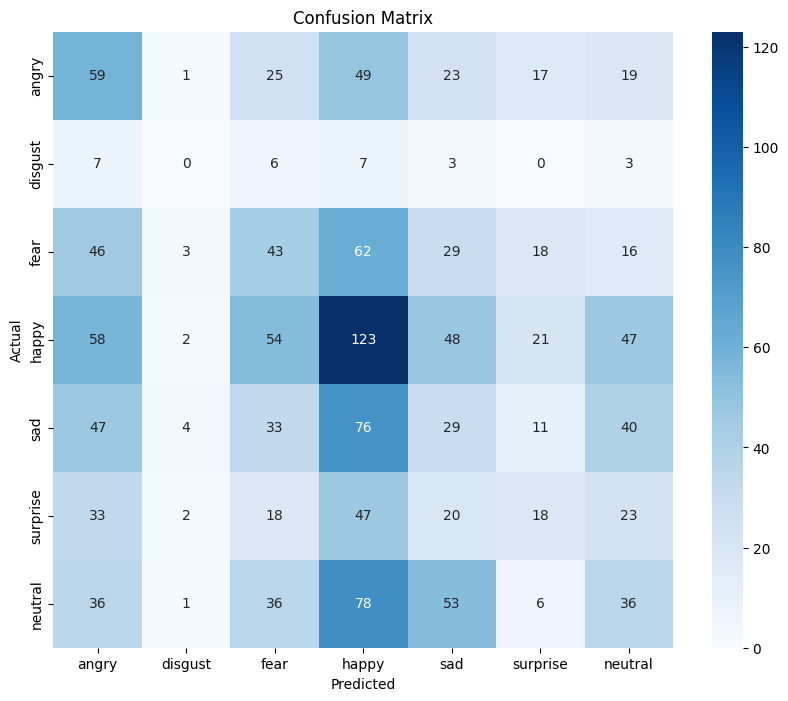

In [8]:
import numpy as np
import cv2
import os
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Step 1: Extract the ZIP
zip_path = "/content/database.zip"
extract_path = "/content/database"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP extracted successfully.")

# Step 2: Define constants and label mapping
LBP_POINTS = 8
LBP_RADIUS = 1
LBP_METHOD = 'uniform'

emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}

# Step 3: Load images and extract LBP features
def load_images_from_folder(base_path):
    features = []
    labels = []
    for emotion, label in emotion_map.items():
        folder_path = os.path.join(base_path, 'test', emotion)
        if not os.path.exists(folder_path):
            print(f"⚠️ Folder not found: {folder_path}")
            continue
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None and img.shape == (48, 48):
                lbp = local_binary_pattern(img, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)
                (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
                hist = hist.astype("float")
                hist /= (hist.sum() + 1e-6)
                features.append(hist)
                labels.append(label)
    return np.array(features), np.array(labels)

# Step 4: Load and preprocess
X, y = load_images_from_folder(extract_path)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = knn.predict(X_test)

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Step 8: Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_map.keys(), yticklabels=emotion_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()




In [12]:
# Importuri necesare
import numpy as np
import cv2
import os
import zipfile
import dlib
import pickle
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# Afișare grafică direct în Jupyter
zip_path = "/content/database.zip"  # Sau încarcă cu File Upload în Jupyter
extract_path = "/content/database"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP extras cu succes.")


✅ ZIP extras cu succes.


In [13]:
LBP_POINTS = 8
LBP_RADIUS = 1
LBP_METHOD = 'uniform'
IMAGE_SIZE = (48, 48)

emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}

detector = dlib.get_frontal_face_detector()


In [14]:
def extract_lbp_features(image):
    lbp = local_binary_pattern(image, P=LBP_POINTS, R=LBP_RADIUS, method=LBP_METHOD)
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, LBP_POINTS + 3), range=(0, LBP_POINTS + 2))
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)
    return hist

def load_images(base_path):
    features = []
    labels = []
    for emotion, label in emotion_map.items():
        folder = os.path.join(base_path, 'test', emotion)
        if not os.path.exists(folder):
            print(f"⚠️ Folder inexistent: {folder}")
            continue
        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            if faces:
                x, y, w, h = faces[0].left(), faces[0].top(), faces[0].width(), faces[0].height()
                face_roi = gray[y:y+h, x:x+w]
                face_resized = cv2.resize(face_roi, IMAGE_SIZE)
            else:
                face_resized = cv2.resize(gray, IMAGE_SIZE)

            hist = extract_lbp_features(face_resized)
            features.append(hist)
            labels.append(label)
    return np.array(features), np.array(labels)


In [15]:
X, y = load_images(extract_path)
print(f"📂 Total imagini procesate: {len(y)}")


📂 Total imagini procesate: 7178


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
y_pred = knn.predict(X_test)

print("📊 Raport de clasificare:")
print(classification_report(y_test, y_pred))


📊 Raport de clasificare:
              precision    recall  f1-score   support

           0       0.21      0.31      0.25       193
           1       0.00      0.00      0.00        26
           2       0.20      0.20      0.20       217
           3       0.28      0.35      0.31       353
           4       0.14      0.12      0.13       240
           5       0.20      0.11      0.14       161
           6       0.20      0.15      0.17       246

    accuracy                           0.21      1436
   macro avg       0.17      0.18      0.17      1436
weighted avg       0.21      0.21      0.21      1436



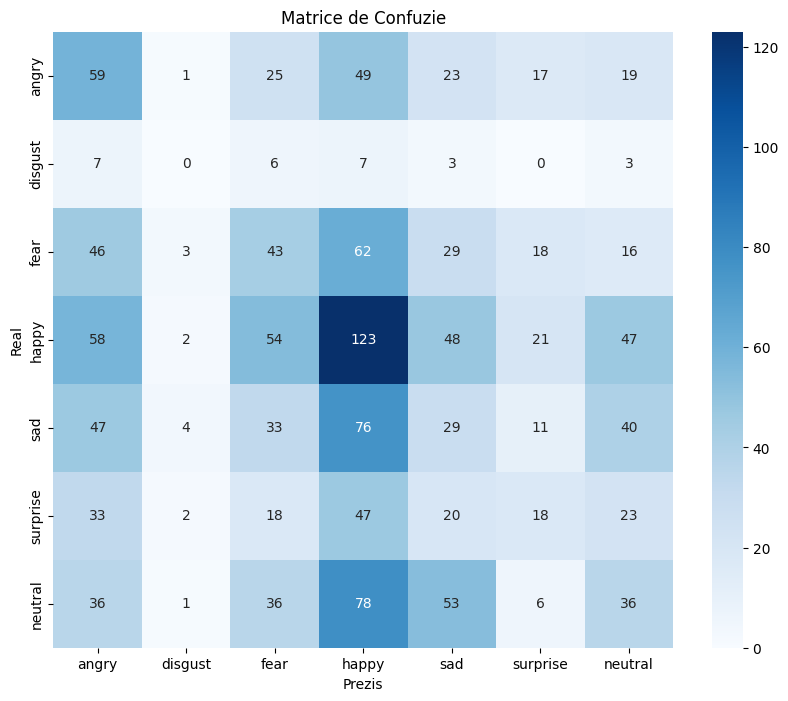

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_map.keys(), yticklabels=emotion_map.keys())
plt.xlabel('Prezis')
plt.ylabel('Real')
plt.title('Matrice de Confuzie')
plt.show()


In [19]:
with open("knn_lbp_model.pkl", 'wb') as f:
    pickle.dump(knn, f)
print("💾 Model salvat cu succes.")


💾 Model salvat cu succes.


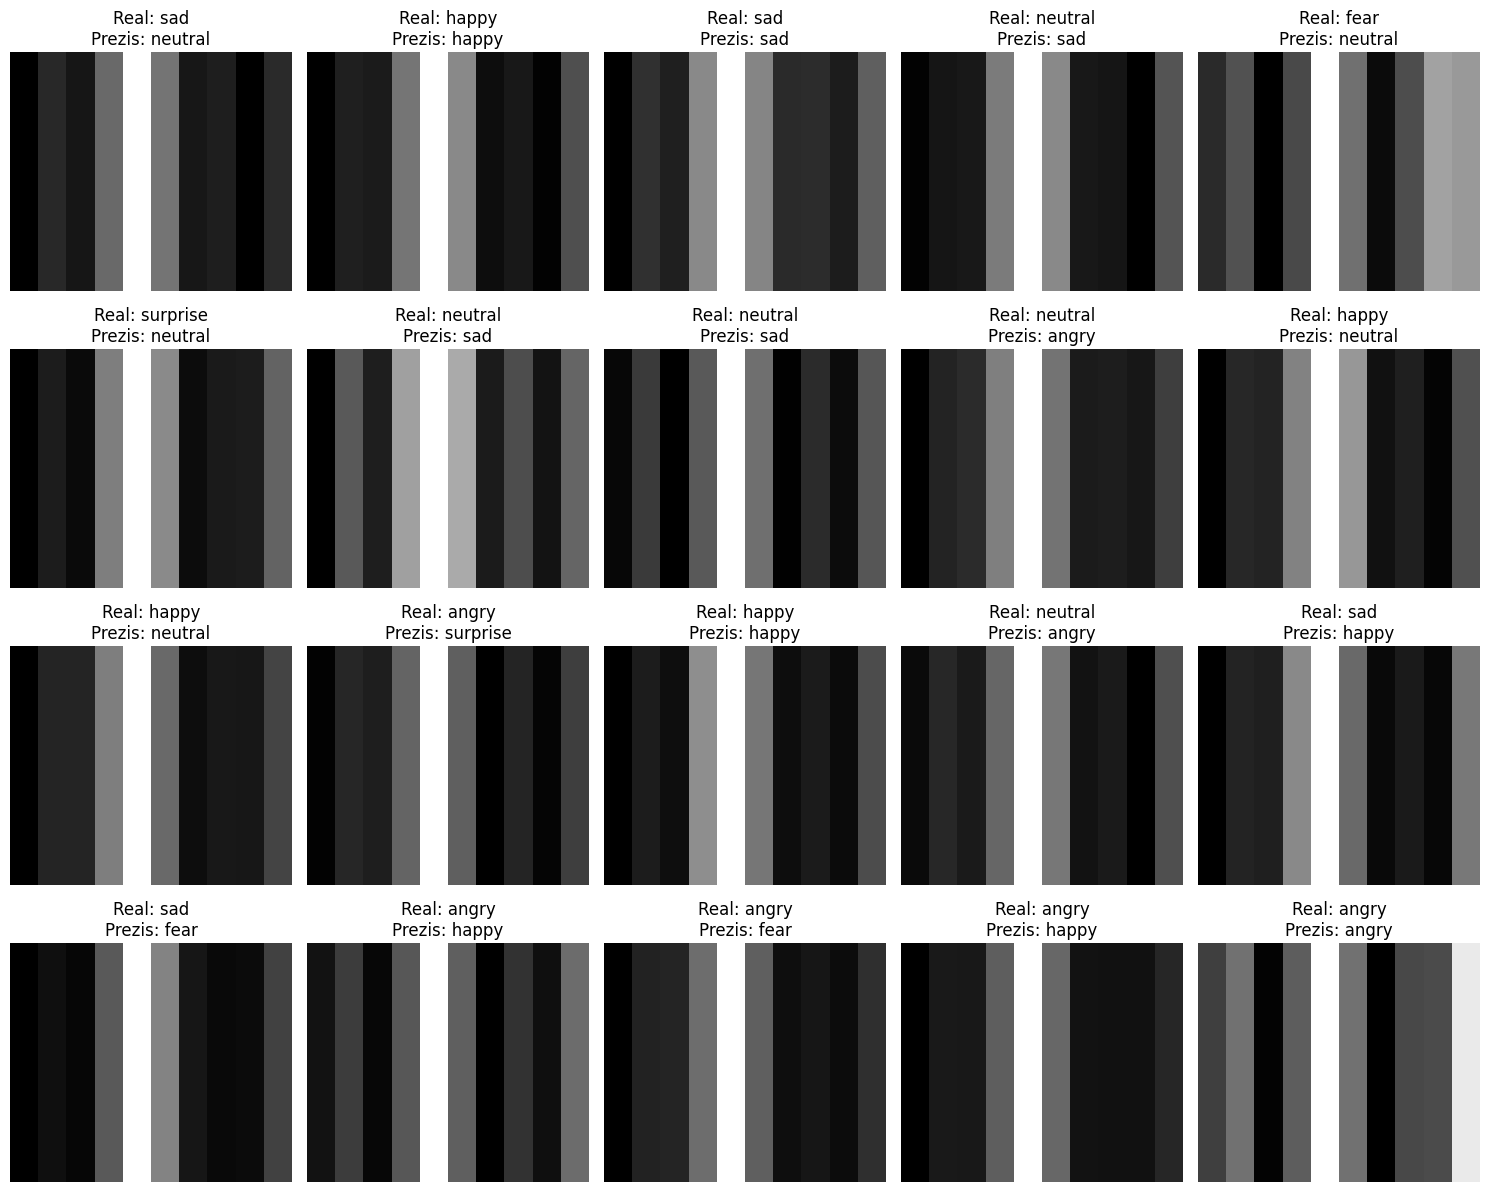

In [20]:
# Afișează predicții individuale pentru fiecare imagine din setul de test
import matplotlib.pyplot as plt

# Mapare inversă: label numeric -> nume emoție
inv_emotion_map = {v: k for k, v in emotion_map.items()}

# Afișare primele N imagini din test
N = 20  # Modifică în funcție de câte vrei să vezi

plt.figure(figsize=(15, 15))
for i in range(min(N, len(X_test))):
    plt.subplot(5, 5, i + 1)
    # Creează o imagine artificială din histograma LBP (doar pentru ilustrație)
    # În realitate nu putem reconstrui fața din histogramă
    fake_image = np.tile(X_test[i], (48, 1))  # Doar o reprezentare grafică
    plt.imshow(fake_image, cmap='gray', aspect='auto')
    plt.title(f"Real: {inv_emotion_map[y_test[i]]}\nPrezis: {inv_emotion_map[y_pred[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
def load_images(base_path):
    features = []
    labels = []
    original_images = []
    for emotion, label in emotion_map.items():
        folder = os.path.join(base_path, 'test', emotion)
        if not os.path.exists(folder):
            print(f"⚠️ Folder inexistent: {folder}")
            continue
        for filename in os.listdir(folder):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)

            if faces:
                x, y, w, h = faces[0].left(), faces[0].top(), faces[0].width(), faces[0].height()
                face_roi = gray[y:y+h, x:x+w]
                face_resized = cv2.resize(face_roi, IMAGE_SIZE)
            else:
                face_resized = cv2.resize(gray, IMAGE_SIZE)

            hist = extract_lbp_features(face_resized)
            features.append(hist)
            labels.append(label)
            original_images.append(face_resized)  # păstrează imaginea folosită

    return np.array(features), np.array(labels), np.array(original_images)


In [22]:
X, y, images = load_images(extract_path)
print(f"📂 Total imagini procesate: {len(y)}")


📂 Total imagini procesate: 7178


In [23]:
X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X, y, images, test_size=0.2, random_state=42
)


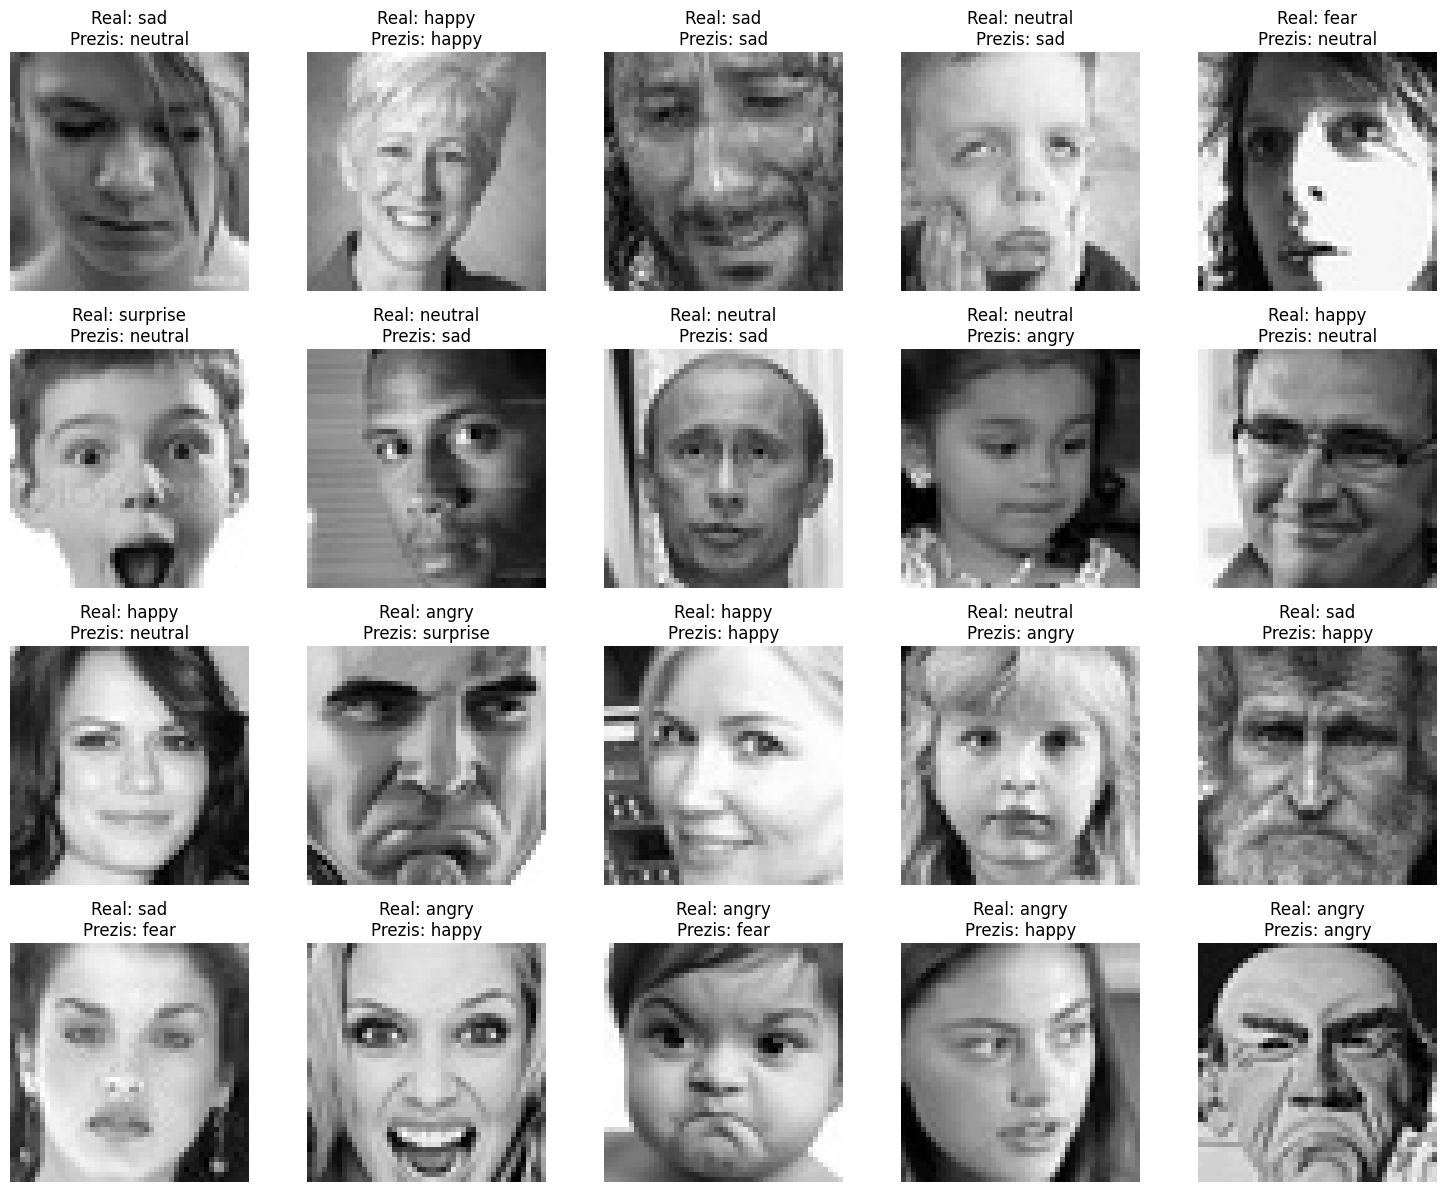

In [24]:
# Mapare inversă pentru etichete
inv_emotion_map = {v: k for k, v in emotion_map.items()}

# Număr de imagini de afișat
N = 20

plt.figure(figsize=(15, 15))
for i in range(min(N, len(X_test))):
    plt.subplot(5, 5, i + 1)
    plt.imshow(img_test[i], cmap='gray')
    plt.title(f"Real: {inv_emotion_map[y_test[i]]}\nPrezis: {inv_emotion_map[y_pred[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
